In [100]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [101]:
np.random.seed(0)

In [102]:
n = 25

d1 = np.random.multivariate_normal(mean=[2, 2], cov=[[0.5, 0], [0, 0.5]], size=n)
d2 = np.random.multivariate_normal(mean=[5, 5], cov=[[0.5, 0], [0, 0.3]], size=n)
d3 = np.random.multivariate_normal(mean=[-2, -2], cov=[[1, 0], [0, 0.9]], size=n)
d4 = np.random.multivariate_normal(mean=[-4, 8], cov=[[0.8, 0], [0, 0.6]], size=n)
d = np.vstack([d1, d2, d3, d4])

In [104]:
wcss = []
for i in range(1,21):
    kmeans = KMeans(i, random_state=0)
    kmeans.fit(d)
    wcss.append(kmeans.inertia_)



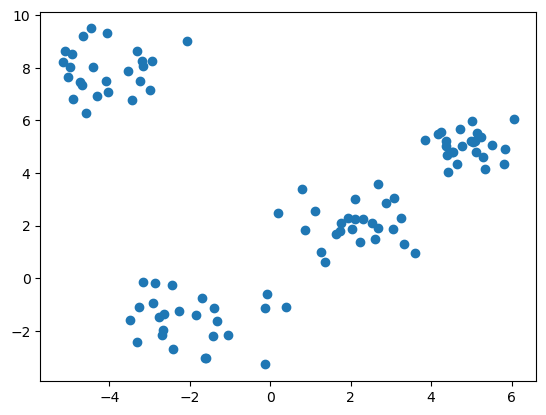

In [114]:
plt.scatter(*d.T)

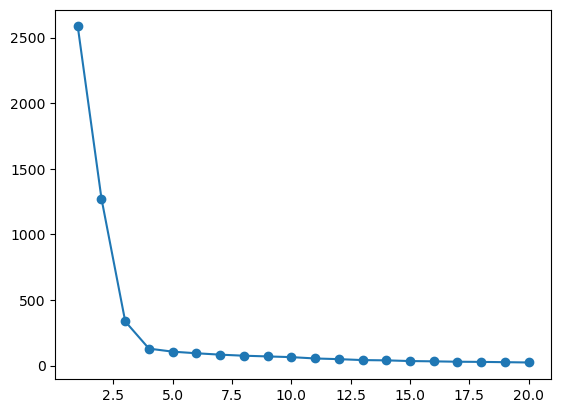

In [118]:
plt.plot(range(1, 21), wcss, marker='o')

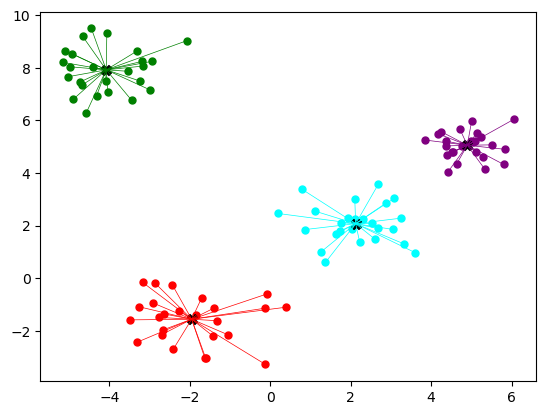

In [115]:

kmeans = KMeans(4, random_state=0)
kmeans.fit(d)
l = kmeans.labels_
c = kmeans.cluster_centers_
colors = ['red','green','purple','cyan']
for i in range(len(d)):
    plt.scatter(*d[i], color=colors[l[i]], s=25)
    cl = c[l[i]]
    plt.plot([cl[0], d[i][0]], [cl[1], d[i][1]], color=colors[l[i]], linewidth=0.5)
for i in c:
    plt.scatter(i[0],i[1], marker='X', color='black', s=50)

### Q1: What might happen if the value of the number of clusters is set too high or too low in K-Means?

The clusters formed from a very low number of clusters causes multiple optimal clusters to be considered as one single cluster, which reduces accuracy.
A high number of clusters unnecessarily splits a single optimal cluster into multiple smaller clusters, making the information less usable.

### Q2: What is the effect of initializing centroids far apart or too close together in K-Means, and how might this affect the final clustering?

The position of initial centroids can lead to different output clusters. If two centroids are initially too close, they can form smaller clusters while other clusters dominate and become larger. 
On the other hand, far apart clusters are used in KMeans++, a more optimal version of KMeans. It has been shown to give better output. 


### Q3: How might you optimise the centroid initialisation to lead to better clustering?

Random centroid initialization is likelier to lead to unoptimal clustering than using far apart clusters. Thus we use KMeans++ which initializes the centroids far away, which is proven to be more reliable and stable.


### Q4: Why might the Elbow Method not always provide a clear solution for choosing the optimal number of clusters?

The decrease could be gradual and an elbow could not be immediately obvious. Thus, instead other methods like silhouette method work better. 


### Q5: How can WCSS be influenced by the presence of outliers or noise in the data?

Outliers can impact the WCSS a lot as they affect the total of distance a lot (as they are far from centroid) and they can also heavily impact the centroid's final position. Thus, KMeans requires good denoising of the data before clustering.